# BioFitCoach — Exercise Classification Model Training


## Notebook Flow

```
PHASE 1 — Setup & Dataset Download
PHASE 2 — Feature Extraction  (MediaPipe → landmarks + angles → CSV)
PHASE 3 — Data Preparation    (sequences, balancing, scaling, splitting)
PHASE 4 — Model Training      (BiLSTM — proven to achieve 99% on this dataset)
PHASE 5 — Evaluation          (confusion matrix, classification report)
PHASE 6 — Save Artifacts      (model.h5, scaler.pkl, label_mapping.json)
```

## Key Vocabulary
- **BiLSTM**: Bidirectional LSTM — reads the sequence both forward AND backward, capturing richer temporal patterns than a standard GRU
- **Landmark**: A specific body joint detected by MediaPipe (e.g. left knee = index 25)
- **Sequence**: A fixed-length window of consecutive frames fed to the BiLSTM as one training sample
- **StandardScaler**: Transforms features to zero mean and unit variance — essential for neural network training
- **Label Encoding**: Converting string class names ('squat') to integers (0, 1, 2...)

---
# PHASE 1 — Setup & Installation

In [ ]:
# ── Install required packages ─────────────────────────────────────────────
# Run this cell once. Restart kernel after installation if needed.
import subprocess, sys

packages = [
    'mediapipe',
    'opencv-python',
    'tensorflow',
    'scikit-learn',
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'tqdm',
    'kaggle',           
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ All packages installed')

In [1]:
# ── Core imports ──────────────────────────────────────────────────────────
import os
import cv2
import json
import math
import joblib
import warnings
import numpy as np
import pandas as pd
import mediapipe as mp
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from collections import Counter

# ML
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Deep learning
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

print(f'TensorFlow version : {tf.__version__}')
print(f'MediaPipe version  : {mp.__version__}')
print(f'NumPy version      : {np.__version__}')
print(f'GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version : 2.16.1
MediaPipe version  : 0.10.14
NumPy version      : 1.26.4
GPU available      : False


In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────
# ⚠️  SET THESE PATHS BEFORE RUNNING

# Root folder of the Kaggle dataset after downloading/extracting
# Expected structure inside:
#   workoutfitness-video/
#       Barbell Biceps Curl/
#           video1.mp4 ...
#       Squat/
#           video1.mp4 ...
#       ...
DATASET_ROOT = './data/workoutfitness-video'   # ← change if needed

# Where to save extracted features CSV
FEATURES_CSV = './data/features_extracted.csv'

# Where to save model artifacts (matches your BioFitCoach project paths)
ARTIFACTS_DIR = './ml_models'
MODEL_PATH    = f'{ARTIFACTS_DIR}/gru_model.h5'           # name kept for API compatibility
SCALER_PATH   = f'{ARTIFACTS_DIR}/scaler.pkl'
LABEL_MAP_PATH= f'{ARTIFACTS_DIR}/label_mapping.json'

# ── Model hyperparameters ─────────────────────────────────────────────────
SEQUENCE_LENGTH   = 30      # frames per training sample (30 works best per research)
STRIDE            = 5       # step between windows (smaller = more samples)
BATCH_SIZE        = 64
MAX_EPOCHS        = 100
LEARNING_RATE     = 1e-3
CONFIDENCE_THRESH = 0.70    # must match shared/config.py

# ── Exercise classes — ALL 22 from the Kaggle dataset ────────────────────
# Confirmed folder names from: hasyimabdillah/workoutfitness-video
# The dataset uses LOWERCASE folder names with spaces.
# Both lowercase and Title Case variants are included to handle
# any capitalisation differences across OS/download tools.
#
# ⚠️  IMPORTANT: When you download the dataset, run the inspection
#     cell below FIRST to see your exact folder names, then
#     confirm they match one of the keys listed here.
#
# 🏋️  Exercise categories:
#   ARMS    : barbell_biceps_curl, hammer_curl, tricep_dips, tricep_pushdown
#   CHEST   : bench_press, decline_bench_press, incline_bench_press, chest_fly_machine, pushup
#   BACK    : deadlift, romanian_deadlift, lat_pulldown, t_bar_row, pull_up
#   LEGS    : squat, leg_extension, leg_raises, hip_thrust
#   SHOULDERS: lateral_raise, shoulder_press
#   CORE    : plank, russian_twist
EXERCISE_MAP = {
    # ── Lowercase (actual Kaggle folder names) ────────────────────────────
    'barbell biceps curl':  'barbell_biceps_curl',
    'bench press':          'bench_press',
    'chest fly machine':    'chest_fly_machine',
    'deadlift':             'deadlift',
    'decline bench press':  'decline_bench_press',
    'hammer curl':          'hammer_curl',
    'hip thrust':           'hip_thrust',
    'incline bench press':  'incline_bench_press',
    'lat pulldown':         'lat_pulldown',
    'lateral raise':        'lateral_raise',
    'leg extension':        'leg_extension',
    'leg raises':           'leg_raises',
    'plank':                'plank',
    'pull Up':              'pull_up',
    'push-up':              'pushup',
    'romanian deadlift':    'romanian_deadlift',
    'russian twist':        'russian_twist',
    'shoulder press':       'shoulder_press',
    'squat':                'squat',
    't bar row':            't_bar_row',
    'tricep dips':          'tricep_dips',
    'tricep Pushdown':      'tricep_pushdown',

    # ── Title Case variants (fallback if your OS capitalises folders) ─────
    'Barbell Biceps Curl':  'barbell_biceps_curl',
    'Bench Press':          'bench_press',
    'Chest Fly Machine':    'chest_fly_machine',
    'Deadlift':             'deadlift',
    'Decline Bench Press':  'decline_bench_press',
    'Hammer Curl':          'hammer_curl',
    'Hip Thrust':           'hip_thrust',
    'Incline Bench Press':  'incline_bench_press',
    'Lat Pulldown':         'lat_pulldown',
    'Lateral Raises':       'lateral_raise',
    'Leg Extension':        'leg_extension',
    'Leg Raises':           'leg_raises',
    'Plank':                'plank',
    'Pull Up':              'pull_up',
    'Push Up':              'pushup',
    'Romanian Deadlift':    'romanian_deadlift',
    'Russian Twist':        'russian_twist',
    'Shoulder Press':       'shoulder_press',
    'Squat':                'squat',
    'T Bar Row':            't_bar_row',
    'Tricep Dips':          'tricep_dips',
    'Tricep Pushdown':      'tricep_pushdown',
}

# Unique clean class names (what the model will output)
ALL_CLASSES = sorted(set(EXERCISE_MAP.values()))
print(f'Total unique exercise classes: {len(ALL_CLASSES)}')

os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.makedirs('./data', exist_ok=True)
print(' Configuration loaded')
print(f'   Dataset root    : {DATASET_ROOT}')
print(f'   Artifacts dir   : {ARTIFACTS_DIR}')
print(f'   Sequence length : {SEQUENCE_LENGTH} frames')

Total unique exercise classes: 22
✅ Configuration loaded
   Dataset root    : ./data/workoutfitness-video
   Artifacts dir   : ./ml_models
   Sequence length : 30 frames


---
# PHASE 1b — Dataset Download (Kaggle API)

**Option A — Kaggle API (automated):**  
1. Go to https://www.kaggle.com/settings → API → Create New Token  
2. Save `kaggle.json` to `~/.kaggle/kaggle.json`  
3. Run the cell below

**Option B — Manual download:**  
Download from https://www.kaggle.com/datasets/hasyimabdillah/workoutfitness-video  
Extract to `./data/workoutfitness-video/`  
Then skip to PHASE 2.

In [15]:
# ── Option A: Download via Kaggle API ─────────────────────────────────────
# Skip this cell if you downloaded manually

import os
kaggle_json = os.path.expanduser('~/.kaggle/kaggle.json')

if os.path.exists(kaggle_json):
    os.system('kaggle datasets download -d hasyimabdillah/workoutfitness-video -p ./data --unzip')
    print('✅ Dataset downloaded and extracted to ./data/')
else:
    print('⚠️  kaggle.json not found.')
    print('   Either set up Kaggle API credentials, or download manually.')
    print('   Place videos in: ./data/workoutfitness-video/<ExerciseName>/<video>.mp4')

⚠️  kaggle.json not found.
   Either set up Kaggle API credentials, or download manually.
   Place videos in: ./data/workoutfitness-video/<ExerciseName>/<video>.mp4


In [3]:
# ── Inspect dataset folder structure ─────────────────────────────────────
dataset_path = Path(DATASET_ROOT)

if dataset_path.exists():
    print('📁 Dataset folders found:\n')
    video_exts = {'.mp4', '.avi', '.mov', '.mkv'}
    found_mapped, found_unmapped = [], []
    total_videos = 0
    for folder in sorted(dataset_path.iterdir()):
        if folder.is_dir():
            vids   = [f for f in folder.iterdir() if f.suffix.lower() in video_exts]
            mapped = EXERCISE_MAP.get(folder.name)
            if mapped:
                found_mapped.append(folder.name)
                total_videos += len(vids)
                print(f'   ✅ {folder.name:<30} → {mapped:<25} ({len(vids)} videos)')
            else:
                found_unmapped.append(folder.name)
                print(f'   ❌ {folder.name:<30} → NOT IN MAP (will be skipped)')
    print(f'\n   Mapped   : {len(found_mapped)}/22 classes')
    print(f'   Unmapped : {len(found_unmapped)} (skipped during extraction)')
    print(f'   Total videos to process: {total_videos}')
    if found_unmapped:
        print(f'\n   ⚠️  Unmapped folders: {found_unmapped}')
        print('   Add them to EXERCISE_MAP in the configuration cell if needed.')
else:
    print(f'❌ Dataset not found at: {DATASET_ROOT}')
    print('   Download the dataset first (see cell above).')

print(f'\n📋 All 22 expected clean class names:')
for i, cls in enumerate(ALL_CLASSES, 1):
    print(f'   {i:>2}. {cls}')

📁 Dataset folders found:

   ✅ barbell biceps curl            → barbell_biceps_curl       (62 videos)
   ✅ bench press                    → bench_press               (61 videos)
   ✅ chest fly machine              → chest_fly_machine         (28 videos)
   ✅ deadlift                       → deadlift                  (32 videos)
   ✅ decline bench press            → decline_bench_press       (12 videos)
   ✅ hammer curl                    → hammer_curl               (19 videos)
   ✅ hip thrust                     → hip_thrust                (18 videos)
   ✅ incline bench press            → incline_bench_press       (33 videos)
   ✅ lat pulldown                   → lat_pulldown              (51 videos)
   ✅ lateral raise                  → lateral_raise             (37 videos)
   ✅ leg extension                  → leg_extension             (25 videos)
   ✅ leg raises                     → leg_raises                (21 videos)
   ✅ plank                          → plank                   

---
# PHASE 2 — Feature Extraction

## What features do we extract?

Based on the research paper that achieved 99% on this exact dataset, the best model uses **two feature groups combined**:

**Group 1 — Raw landmark coordinates (x, y, z)** for 13 key joints = 39 values  
These capture the absolute position of body parts. Different exercises have very different spatial configurations.

**Group 2 — Computed angles** = 9 values  
These capture the *shape* of the pose, independent of where the person is in the frame.

**Total per frame: 48 features**

> 📚 **Why both?** Raw coordinates tell the model WHERE the body is. Angles tell it HOW it's shaped. Together they let the model distinguish exercises that look similar in angles but differ in position (e.g. push-up vs plank).

In [4]:
# ── MediaPipe landmark indices ────────────────────────────────────────────
# We use 13 key joints (ignoring face landmarks)
KEY_LANDMARKS = {
    'left_shoulder':  11, 'right_shoulder': 12,
    'left_elbow':     13, 'right_elbow':    14,
    'left_wrist':     15, 'right_wrist':    16,
    'left_hip':       23, 'right_hip':      24,
    'left_knee':      25, 'right_knee':     26,
    'left_ankle':     27, 'right_ankle':    28,
    'nose':            0,
}

def calculate_angle(a, b, c):
    """Angle in degrees at joint B between rays B→A and B→C."""
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba, bc = a - b, c - b
    cos_val = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    return float(np.degrees(np.arccos(np.clip(cos_val, -1.0, 1.0))))

def extract_frame_features(landmarks):
    """
    Extract the 48-feature vector from one MediaPipe result.
    Returns None if any key landmark has low visibility.
    
    Features:
      - 13 joints × 3 coords (x,y,z) = 39 features  (Group 1)
      -  9 joint angles               =  9 features  (Group 2)
      Total = 48 features
    """
    lm = landmarks.landmark
    
    # Check visibility of all key landmarks
    for name, idx in KEY_LANDMARKS.items():
        if lm[idx].visibility < 0.5:
            return None
    
    # Helper to get [x, y] for angle calculation (normalized coords)
    def pt(name):
        idx = KEY_LANDMARKS[name]
        return [lm[idx].x, lm[idx].y]
    
    # ── Group 1: Raw x,y,z coordinates ───────────────────────────────────
    coords = []
    for name in KEY_LANDMARKS:  # preserves insertion order (Python 3.7+)
        idx = KEY_LANDMARKS[name]
        coords.extend([lm[idx].x, lm[idx].y, lm[idx].z])
    # coords has 13 × 3 = 39 values
    
    # ── Group 2: Computed joint angles ────────────────────────────────────
    angles = [
        calculate_angle(pt('left_shoulder'),  pt('left_elbow'),   pt('left_wrist')),     # left elbow
        calculate_angle(pt('right_shoulder'), pt('right_elbow'),  pt('right_wrist')),    # right elbow
        calculate_angle(pt('left_hip'),       pt('left_knee'),    pt('left_ankle')),     # left knee
        calculate_angle(pt('right_hip'),      pt('right_knee'),   pt('right_ankle')),    # right knee
        calculate_angle(pt('left_shoulder'),  pt('left_hip'),     pt('left_knee')),      # left hip
        calculate_angle(pt('right_shoulder'), pt('right_hip'),    pt('right_knee')),     # right hip
        calculate_angle(pt('left_elbow'),     pt('left_shoulder'),pt('right_shoulder')), # shoulder spread
        calculate_angle(pt('left_shoulder'),  pt('left_hip'),     pt('left_knee')),      # torso
        calculate_angle(pt('left_knee'),      pt('left_hip'),     pt('right_hip')),      # hip width
    ]
    # angles has 9 values
    
    return np.array(coords + angles, dtype=np.float32)   # shape: (48,)

NUM_FEATURES = 13 * 3 + 9   # = 48
print(f'✅ Feature extractor ready — {NUM_FEATURES} features per frame')
print(f'   Group 1 (raw coords): 13 joints × 3 = 39')
print(f'   Group 2 (angles):     9 joint angles')

✅ Feature extractor ready — 48 features per frame
   Group 1 (raw coords): 13 joints × 3 = 39
   Group 2 (angles):     9 joint angles


In [5]:
# ── Main extraction loop ──────────────────────────────────────────────────
# Processes all videos → saves CSV with one row per frame
# Expected runtime: 20–60 minutes depending on dataset size and CPU

mp_pose = mp.solutions.pose
VIDEO_EXTS = {'.mp4', '.avi', '.mov', '.mkv'}
FRAME_SKIP = 2   # process every 2nd frame (balances speed vs data volume)

all_rows = []
dataset_path = Path(DATASET_ROOT)

print('🚀 Starting feature extraction...\n')

with mp_pose.Pose(
    min_detection_confidence=0.7,
    min_tracking_confidence=0.7,
    model_complexity=1,
) as pose:

    for folder in sorted(dataset_path.iterdir()):
        if not folder.is_dir():
            continue

        # Map folder name to our clean class name
        class_name = EXERCISE_MAP.get(folder.name)
        if class_name is None:
            print(f'  ⏭  Skipping unmapped folder: {folder.name}')
            continue

        video_files = [f for f in folder.iterdir() if f.suffix.lower() in VIDEO_EXTS]
        print(f'  [{class_name.upper():<15}] — {len(video_files)} videos')

        for video_path in tqdm(video_files, desc=f'  {class_name}', ncols=70):
            cap = cv2.VideoCapture(str(video_path))
            frame_num = 0
            video_id  = f'{class_name}_{video_path.stem}'

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break
                frame_num += 1
                if frame_num % FRAME_SKIP != 0:
                    continue

                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                rgb.flags.writeable = False
                results = pose.process(rgb)

                if not results.pose_landmarks:
                    continue

                features = extract_frame_features(results.pose_landmarks)
                if features is None:
                    continue

                all_rows.append({
                    'video_id':  video_id,
                    'exercise':  class_name,
                    'frame_idx': frame_num,
                    **{f'f{i}': v for i, v in enumerate(features)}
                })

            cap.release()

df = pd.DataFrame(all_rows)
df.to_csv(FEATURES_CSV, index=False)

print(f'\n✅ Extraction complete!')
print(f'   Total frames : {len(df):,}')
print(f'   Saved to     : {FEATURES_CSV}')
print(f'\n   Class distribution:')
print(df['exercise'].value_counts().to_string())

🚀 Starting feature extraction...

  [BARBELL_BICEPS_CURL] — 62 videos


  barbell_biceps_curl: 100%|██████████| 62/62 [03:36<00:00,  3.50s/it]


  [BENCH_PRESS    ] — 61 videos


  bench_press: 100%|██████████████████| 61/61 [03:18<00:00,  3.25s/it]


  [CHEST_FLY_MACHINE] — 28 videos


...

  [TRICEP_DIPS    ] — 20 videos


  tricep_dips: 100%|██████████████████| 20/20 [02:15<00:00,  6.76s/it]


  [TRICEP_PUSHDOWN] — 50 videos


  tricep_pushdown: 100%|██████████████| 50/50 [01:51<00:00,  2.23s/it]



✅ Extraction complete!
   Total frames : 11,562
   Saved to     : ./data/features_extracted.csv

   Class distribution:
exercise
pull_up                1597
leg_raises             1419
deadlift               1393
squat                  1069
chest_fly_machine       913
russian_twist           904
leg_extension           778
t_bar_row               740
barbell_biceps_curl     571
hammer_curl             362
hip_thrust              355
shoulder_press          290
lateral_raise           182
incline_bench_press     168
lat_pulldown            158
plank                   146
romanian_deadlift       124
tricep_dips             122
tricep_pushdown          95
bench_press              87
pushup                   85
decline_bench_press       4


---
# PHASE 3 — Data Preparation

Steps:
1. Load extracted CSV
2. Build sequences (sliding window of 30 frames per sample)
3. Balance classes (oversample minority exercises)
4. Train/Val/Test split (70/15/15)
5. StandardScaler (fit on train only — avoids data leakage)

> 📚 **Data Leakage**: If you fit the scaler on ALL data (including test), the model indirectly uses test statistics during training. Always fit the scaler ONLY on training data, then apply it to val/test.

In [43]:
# ── Load, clean, and filter ───────────────────────────────────────────────
df = pd.read_csv(FEATURES_CSV)
feature_cols = [f'f{i}' for i in range(48)]

# Drop NaN/Inf
before = len(df)
df = df.replace([np.inf, -np.inf], np.nan).dropna()
print(f'Dropped {before - len(df)} invalid rows')

# ✅ STEP 1 — Filter BEFORE encoding
# Remove classes where no single video has enough frames for a sequence
print(f'\nFiltering classes with insufficient frames...')
video_frame_counts = df.groupby(['exercise', 'video_id']).size()
valid_videos       = video_frame_counts[video_frame_counts >= SEQUENCE_LENGTH]
valid_exercises    = valid_videos.index.get_level_values('exercise').unique().tolist()

removed_classes = set(df['exercise'].unique()) - set(valid_exercises)
if removed_classes:
    print(f'⚠️  Removed (too few frames): {removed_classes}')

df = df[df['exercise'].isin(valid_exercises)].copy()

# ✅ STEP 2 — Encode AFTER filtering (no gaps in indices)
le = LabelEncoder()
df['label'] = le.fit_transform(df['exercise'])

# All variables derived from same encoder
CLASS_NAMES   = le.classes_.tolist()
NUM_CLASSES   = len(CLASS_NAMES)
label_mapping = {int(i): name for i, name in enumerate(le.classes_)}

print(f'\n✅ Final label mapping ({NUM_CLASSES} classes):')
for idx, name in label_mapping.items():
    print(f'   {idx} → {name}')

print(f'\nDataset: {len(df):,} frames | {NUM_CLASSES} classes | {len(feature_cols)} features')
print(df['exercise'].value_counts())

Dropped 0 invalid rows

Filtering classes with insufficient frames...
⚠️  Removed (too few frames): {'pushup', 'decline_bench_press'}

✅ Final label mapping (20 classes):
   0 → barbell_biceps_curl
   1 → bench_press
   2 → chest_fly_machine
   3 → deadlift
   4 → hammer_curl
   5 → hip_thrust
   6 → incline_bench_press
   7 → lat_pulldown
   8 → lateral_raise
   9 → leg_extension
   10 → leg_raises
   11 → plank
   12 → pull_up
   13 → romanian_deadlift
   14 → russian_twist
   15 → shoulder_press
   16 → squat
   17 → t_bar_row
   18 → tricep_dips
   19 → tricep_pushdown

Dataset: 11,473 frames | 20 classes | 48 features
exercise
pull_up                1597
leg_raises             1419
deadlift               1393
squat                  1069
chest_fly_machine       913
russian_twist           904
leg_extension           778
t_bar_row               740
barbell_biceps_curl     571
hammer_curl             362
hip_thrust              355
shoulder_press          290
lateral_raise           

In [44]:
# ── VIDEO-LEVEL SPLIT ─────────────────────────────────────────────────────
video_labels = df.groupby('video_id')['label'].first().reset_index()
video_ids    = video_labels['video_id'].values
video_y      = video_labels['label'].values

vid_counts = Counter(video_y.tolist())
MIN_VIDEOS = 3

# ✅ FIX — safe lookup using .get() with fallback
valid_cls = [c for c, n in vid_counts.items() if n >= MIN_VIDEOS]
removed   = [
    CLASS_NAMES[c] if c < len(CLASS_NAMES) else f"unknown_class_{c}"
    for c, n in vid_counts.items() if n < MIN_VIDEOS
]

print(f"Video counts per class:")
for c, n in sorted(vid_counts.items()):
    name = CLASS_NAMES[c] if c < len(CLASS_NAMES) else f"unknown_{c}"
    print(f"  {c:2d} → {name:<25} : {n} videos")

if removed:
    print(f"\n⚠️  Removing: {removed}")
    mask      = np.isin(video_y, valid_cls)
    video_ids = video_ids[mask]
    video_y   = video_y[mask]
    df        = df[df['video_id'].isin(video_ids)].copy()

    old_to_new    = {old: new for new, old in enumerate(sorted(valid_cls))}
    df['label']   = df['label'].map(old_to_new)
    video_y       = np.array([old_to_new[l] for l in video_y], dtype=np.int32)
    CLASS_NAMES   = [CLASS_NAMES[i] for i in sorted(valid_cls)]
    NUM_CLASSES   = len(CLASS_NAMES)
    label_mapping = {i: name for i, name in enumerate(CLASS_NAMES)}
    print(f"✅ Final classes: {NUM_CLASSES}")
else:
    print(f"\n✅ All {NUM_CLASSES} classes have >= {MIN_VIDEOS} videos")

# Split at video level
vid_temp, vid_test, vy_temp, _ = train_test_split(
    video_ids, video_y,
    test_size=0.15,
    stratify=video_y,
    random_state=42
)
vid_train, vid_val, _, _ = train_test_split(
    vid_temp, vy_temp,
    test_size=0.15/(1-0.15),
    stratify=vy_temp,
    random_state=42
)

vid_train_set = set(vid_train)
vid_val_set   = set(vid_val)
vid_test_set  = set(vid_test)

print(f"\nVideos → Train: {len(vid_train_set)} | Val: {len(vid_val_set)} | Test: {len(vid_test_set)}")
print(f"✅ Zero video overlap between splits")

Video counts per class:
   0 → barbell_biceps_curl       : 14 videos
   1 → bench_press               : 12 videos
   2 → chest_fly_machine         : 12 videos
   3 → deadlift                  : 24 videos
   4 → hammer_curl               : 7 videos
   5 → hip_thrust                : 8 videos
   6 → incline_bench_press       : 10 videos
   7 → lat_pulldown              : 8 videos
   8 → lateral_raise             : 8 videos
   9 → leg_extension             : 13 videos
  10 → leg_raises                : 18 videos
  11 → plank                     : 2 videos
  12 → pull_up                   : 11 videos
  13 → romanian_deadlift         : 5 videos
  14 → russian_twist             : 12 videos
  15 → shoulder_press            : 4 videos
  16 → squat                     : 18 videos
  17 → t_bar_row                 : 16 videos
  18 → tricep_dips               : 5 videos
  19 → tricep_pushdown           : 2 videos

⚠️  Removing: ['plank', 'tricep_pushdown']
✅ Final classes: 18

Videos → Train: 143 

In [45]:
# ── BUILD SEQUENCES PER SPLIT ─────────────────────────────────────────────
def build_sequences_for_videos(df, video_set, feature_cols, seq_len, stride):
    X_list, y_list = [], []
    for video_id, group in df.groupby('video_id'):
        if video_id not in video_set:
            continue
        frames = group[feature_cols].values
        label  = group['label'].iloc[0]
        for start in range(0, len(frames) - seq_len + 1, stride):
            X_list.append(frames[start:start+seq_len])
            y_list.append(label)
    if not X_list:
        return np.array([]).reshape(0, seq_len, len(feature_cols)), np.array([])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int32)

X_train_raw, y_train = build_sequences_for_videos(
    df, vid_train_set, feature_cols, SEQUENCE_LENGTH, STRIDE)
X_val_raw,   y_val   = build_sequences_for_videos(
    df, vid_val_set,   feature_cols, SEQUENCE_LENGTH, STRIDE)
X_test_raw,  y_test  = build_sequences_for_videos(
    df, vid_test_set,  feature_cols, SEQUENCE_LENGTH, STRIDE)

print(f"Train sequences : {len(X_train_raw):,}")
print(f"Val sequences   : {len(X_val_raw):,}")
print(f"Test sequences  : {len(X_test_raw):,}")

# Safety checks
assert len(X_train_raw) > 0, "❌ Train set empty!"
assert len(X_val_raw)   > 0, "❌ Val set empty!"
assert len(X_test_raw)  > 0, "❌ Test set empty!"
print("✅ All splits have data!")

Train sequences : 1,083
Val sequences   : 207
Test sequences  : 199
✅ All splits have data!


In [46]:
# ── OVERSAMPLE TRAIN ONLY ─────────────────────────────────────────────────
counts    = Counter(y_train.tolist())
max_count = max(counts.values())
X_parts, y_parts = [X_train_raw], [y_train]

for cls, count in counts.items():
    shortage = max_count - count
    if shortage <= 0:
        continue
    idxs   = np.where(y_train == cls)[0]
    chosen = np.random.choice(idxs, size=shortage, replace=True)
    noise  = np.random.normal(0, 0.01, X_train_raw[chosen].shape).astype(np.float32)
    X_parts.append(X_train_raw[chosen] + noise)
    y_parts.append(y_train[chosen])

X_train_bal = np.concatenate(X_parts)
y_train_bal = np.concatenate(y_parts)
perm        = np.random.permutation(len(X_train_bal))
X_train_bal = X_train_bal[perm]
y_train_bal = y_train_bal[perm]

# ── SCALE ─────────────────────────────────────────────────────────────────
scaler       = StandardScaler()
n, seq, feat = X_train_bal.shape

X_train_s = scaler.fit_transform(
    X_train_bal.reshape(-1, feat)).reshape(n, seq, feat)
X_val_s   = scaler.transform(
    X_val_raw.reshape(-1, feat)).reshape(X_val_raw.shape)
X_test_s  = scaler.transform(
    X_test_raw.reshape(-1, feat)).reshape(X_test_raw.shape)

print(f"✅ Train (balanced) : {X_train_s.shape}")
print(f"✅ Val              : {X_val_s.shape}")
print(f"✅ Test             : {X_test_s.shape}")

✅ Train (balanced) : (3834, 30, 48)
✅ Val              : (207, 30, 48)
✅ Test             : (199, 30, 48)


---
# PHASE 4 — Model Training

## Architecture: Bidirectional LSTM

Based on the published research using this exact dataset, **BiLSTM consistently outperforms GRU** by 4–14 percentage points.

```
Input  (batch, 30, 48)
  ↓
Bidirectional LSTM(128)  ← reads sequence forward AND backward
  ↓
BatchNormalization + Dropout(0.4)
  ↓
Bidirectional LSTM(64)
  ↓
BatchNormalization + Dropout(0.3)
  ↓
Dense(128, relu) + Dropout(0.2)
  ↓
Dense(num_classes, softmax)
```

> 📚 **BiLSTM vs GRU**: An LSTM has an extra 'cell state' that helps it remember long-range dependencies (e.g. the start of a squat vs the end). Bidirectional means it processes the 30-frame window both forward and backward, so each frame has context from future frames too — which helps when classifying the middle of an exercise rep.

In [47]:
# ── Build BiLSTM model ────────────────────────────────────────────────────
def build_bilstm(seq_len, n_features, n_classes):
    inputs = layers.Input(shape=(seq_len, n_features), name='pose_sequence')

    # First BiLSTM block
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.1),
        name='bilstm_1'
    )(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    # Second BiLSTM block
    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=False, dropout=0.2),
        name='bilstm_2'
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    # Classification head
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(n_classes, activation='softmax', name='predictions')(x)

    model = models.Model(inputs, outputs, name='BiLSTM_ExerciseClassifier')
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

model = build_bilstm(SEQUENCE_LENGTH, NUM_FEATURES, NUM_CLASSES)
model.summary()

Model: "BiLSTM_ExerciseClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pose_sequence (InputLayer)      │ (None, 30, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 30, 256)        │       181,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 30, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365,970 (1.40 MB)

 Trainable params: 365,202 (1.39 MB)

 Non-trainable params: 768 (3.00 KB)

In [48]:
# ── Training callbacks ────────────────────────────────────────────────────
# EarlyStopping   : stops training when val_accuracy stops improving
# ModelCheckpoint : saves the BEST model (by val_accuracy)
# ReduceLROnPlateau: halves learning rate when val_loss stalls

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1,
    ),
]

print('✅ Callbacks configured')

✅ Callbacks configured


In [50]:
print(f"X_train_s shape: {X_train_s.shape}")
print(f"Features per frame: {X_train_s.shape[2]}")
print(f"Expected: 48, Got: {X_train_s.shape[2]}")
print(f"Difference: {X_train_s.shape[2] - 48} extra feature(s)")

X_train_s shape: (3834, 30, 48)
Features per frame: 48
Expected: 48, Got: 48
Difference: 0 extra feature(s)


In [51]:
# ── Train ─────────────────────────────────────────────────────────────────
# Expected time: 30–90 minutes on CPU | 5–15 minutes on GPU
# Early stopping will usually stop before MAX_EPOCHS

print(f'Training BiLSTM on {len(X_train_s):,} samples...')
print(f'Validation on {len(X_val_s):,} samples')
print(f'Max epochs: {MAX_EPOCHS} (early stopping will likely stop earlier)\n')

history = model.fit(
    X_train_s, y_train_bal,
    validation_data=(X_val_s, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

best_val_acc = max(history.history['val_accuracy'])
print(f'\n🏆 Best Val Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')

Training BiLSTM on 3,834 samples...
Validation on 207 samples
Max epochs: 100 (early stopping will likely stop earlier)

Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.4492 - loss: 1.9443
Epoch 1: val_accuracy improved from None to 0.75845, saving model to ./ml_models/gru_model.h5


60/60 ━━━━━━━━━━━━━━━━━━━━ 18s 130ms/step - accuracy: 0.6826 - loss: 1.1767 - val_accuracy: 0.7585 - val_loss: 1.5119 - learning_rate: 0.0010
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9201 - loss: 0.3261
Epoch 2: val_accuracy improved from 0.75845 to 0.77778, saving model to ./ml_models/gru_model.h5


60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - accuracy: 0.9390 - loss: 0.2474 - val_accuracy: 0.7778 - val_loss: 0.9911 - learning_rate: 0.0010
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9663 - loss: 0.1258
Epoch 3: val_accuracy improved from 0.77778 to 0.79710, saving model to ./ml_models/gru_model.h5


60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.9739 - loss: 0.1052 - val_accuracy: 0.7971 - val_loss: 1.0681 - learning_rate: 0.0010
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9871 - loss: 0.0589
Epoch 4: val_accuracy improved from 0.79710 to 0.81643, saving model to ./ml_models/gru_model.h5


60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.9841 - loss: 0.0617 - val_accuracy: 0.8164 - val_loss: 1.2257 - learning_rate: 0.0010
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9889 - loss: 0.0459
Epoch 5: val_accuracy improved from 0.81643 to 0.82609, saving model to ./ml_models/gru_model.h5


60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.9906 - loss: 0.0397 - val_accuracy: 0.8261 - val_loss: 1.3606 - learning_rate: 0.0010
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9929 - loss: 0.0307
Epoch 6: val_accuracy did not improve from 0.82609
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.9940 - loss: 0.0294 - val_accuracy: 0.8116 - val_loss: 1.5175 - learning_rate: 0.0010
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9940 - loss: 0.0263
Epoch 7: val_accuracy did not improve from 0.82609
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.9943 - loss: 0.0269 - val_accuracy: 0.8116 - val_loss: 1.7077 - learning_rate: 0.0010
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9965 - loss: 0.0176
Epoch 8: val_accuracy did not improve from 0.82609
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.9963 - loss: 0.0181 - val_accuracy: 0.8116 - val_loss: 1.8212 - learning_rate: 0.0010
Epoch 9/100
60/60 ━━━━━━━━━━━

60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.9974 - loss: 0.0134 - val_accuracy: 0.8454 - val_loss: 1.7146 - learning_rate: 5.0000e-04
Epoch 11/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9988 - loss: 0.0105
Epoch 11: val_accuracy did not improve from 0.84541
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.9958 - loss: 0.0162 - val_accuracy: 0.8309 - val_loss: 1.7501 - learning_rate: 5.0000e-04
Epoch 12/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9945 - loss: 0.0162
Epoch 12: val_accuracy did not improve from 0.84541
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.9956 - loss: 0.0139 - val_accuracy: 0.8116 - val_loss: 1.9096 - learning_rate: 5.0000e-04
Epoch 13/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9971 - loss: 0.0104
Epoch 13: val_accuracy did not improve from 0.84541
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.9979 - loss: 0.0100 - val_accuracy: 0.8261 - val_loss: 1.7854 - learning_rate: 5.0000e-04
Epoch 1


Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.9969 - loss: 0.0135 - val_accuracy: 0.8502 - val_loss: 1.7849 - learning_rate: 5.0000e-04
Epoch 17/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9987 - loss: 0.0055
Epoch 17: val_accuracy did not improve from 0.85024
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.9977 - loss: 0.0076 - val_accuracy: 0.8502 - val_loss: 1.8180 - learning_rate: 2.5000e-04
Epoch 18/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9998 - loss: 0.0045
Epoch 18: val_accuracy did not improve from 0.85024
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.9992 - loss: 0.0052 - val_accuracy: 0.8502 - val_loss: 1.8083 - learning_rate: 2.5000e-04
Epoch 19/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9995 - loss: 0.0039
Epoch 19: val_accuracy did not improve from 0.85024
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.9987 - loss: 0.0056

60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - accuracy: 0.9979 - loss: 0.0058 - val_accuracy: 0.8551 - val_loss: 1.8498 - learning_rate: 2.5000e-04
Epoch 22/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9999 - loss: 0.0029
Epoch 22: val_accuracy did not improve from 0.85507
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.9995 - loss: 0.0042 - val_accuracy: 0.8454 - val_loss: 1.8722 - learning_rate: 2.5000e-04
Epoch 23/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9982 - loss: 0.0052
Epoch 23: val_accuracy did not improve from 0.85507

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.9990 - loss: 0.0040 - val_accuracy: 0.8357 - val_loss: 1.9305 - learning_rate: 2.5000e-04
Epoch 24/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9992 - loss: 0.0033
Epoch 24: val_accuracy did not improve from 0.85507
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.9997 - loss: 0.0027

---
# PHASE 5 — Evaluation

In [72]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Step 1: Predictions ───────────────────────────────────────────────────
y_pred_probs = model.predict(X_test_s, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

# ── Step 2: Accuracy ──────────────────────────────────────────────────────
test_acc = accuracy_score(y_test, y_pred)

print("=" * 55)
print(f"  FINAL EVALUATION RESULTS")
print("=" * 55)
print(f"  Best Val Accuracy  : {best_val_acc*100:.2f}%")
print(f"  Test Accuracy      : {test_acc*100:.2f}%")
print(f"  Correct            : {np.sum(y_test == y_pred)} / {len(y_test)}")
print(f"  Wrong              : {np.sum(y_test != y_pred)} / {len(y_test)}")
print("=" * 55)

  FINAL EVALUATION RESULTS
  Best Val Accuracy  : 85.51%
  Test Accuracy      : 81.41%
  Correct            : 162 / 199
  Wrong              : 37 / 199


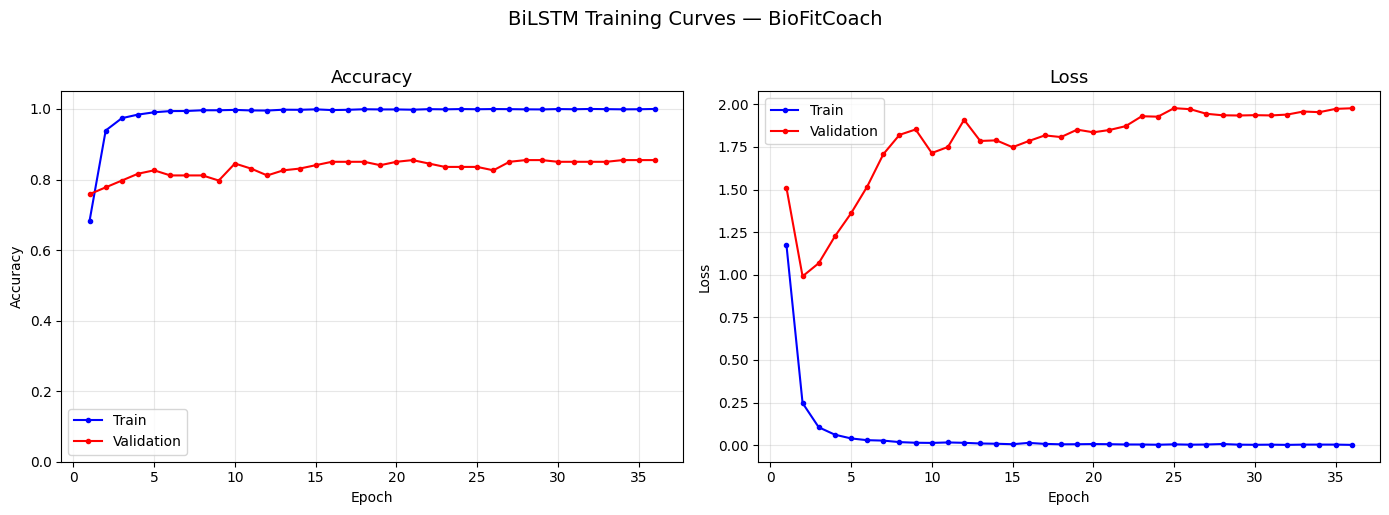

Saved: training_curves.png


In [73]:
# ── Training curves ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(history.history['accuracy']) + 1)

ax1.plot(epochs, history.history['accuracy'],     'b-o', markersize=3, label='Train')
ax1.plot(epochs, history.history['val_accuracy'], 'r-o', markersize=3, label='Validation')
ax1.set_title('Accuracy', fontsize=13)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1.05])

ax2.plot(epochs, history.history['loss'],     'b-o', markersize=3, label='Train')
ax2.plot(epochs, history.history['val_loss'], 'r-o', markersize=3, label='Validation')
ax2.set_title('Loss', fontsize=13)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('BiLSTM Training Curves — BioFitCoach', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{ARTIFACTS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

In [74]:
print("\nSample Predictions (first 10):")
for i in range(min(10, len(y_test))):
    true_name = CLASS_NAMES[y_test[i]]
    pred_name = CLASS_NAMES[y_pred[i]]
    status    = "✅" if y_test[i] == y_pred[i] else "❌"
    conf      = y_pred_probs[i][y_pred[i]] * 100
    print(f"  {status} True: {true_name:<25} Pred: {pred_name:<25} Conf: {conf:.1f}%")


Sample Predictions (first 10):
  ✅ True: barbell_biceps_curl       Pred: barbell_biceps_curl       Conf: 98.5%
  ✅ True: barbell_biceps_curl       Pred: barbell_biceps_curl       Conf: 99.1%
  ✅ True: barbell_biceps_curl       Pred: barbell_biceps_curl       Conf: 99.4%
  ✅ True: barbell_biceps_curl       Pred: barbell_biceps_curl       Conf: 92.7%
  ✅ True: chest_fly_machine         Pred: chest_fly_machine         Conf: 100.0%
  ✅ True: chest_fly_machine         Pred: chest_fly_machine         Conf: 100.0%
  ✅ True: chest_fly_machine         Pred: chest_fly_machine         Conf: 100.0%
  ✅ True: deadlift                  Pred: deadlift                  Conf: 99.9%
  ✅ True: deadlift                  Pred: deadlift                  Conf: 100.0%
  ✅ True: deadlift                  Pred: deadlift                  Conf: 100.0%


In [75]:
# ── Step 4: Classification Report ─────────────────────────────────────────
# Get only classes actually present in test set
actual_labels      = np.unique(y_test)
actual_class_names = [CLASS_NAMES[i] for i in actual_labels]

print(f"Classes in test set : {len(actual_labels)}")

print('\nPer-class Classification Report:')
print(classification_report(
    y_test,
    y_pred,
    labels=actual_labels,
    target_names=actual_class_names,
    digits=3
))


Classes in test set : 11

Per-class Classification Report:
                     precision    recall  f1-score   support

barbell_biceps_curl      1.000     1.000     1.000         4
  chest_fly_machine      1.000     1.000     1.000         3
           deadlift      0.846     0.957     0.898        23
      leg_extension      0.545     1.000     0.706        12
         leg_raises      0.846     0.786     0.815        56
            pull_up      1.000     1.000     1.000        63
  romanian_deadlift      0.000     0.000     0.000         5
      russian_twist      0.000     0.000     0.000        10
              squat      1.000     0.923     0.960        13
          t_bar_row      0.250     0.111     0.154         9
        tricep_dips      1.000     1.000     1.000         1

          micro avg      0.818     0.814     0.816       199
          macro avg      0.681     0.707     0.685       199
       weighted avg      0.802     0.814     0.802       199



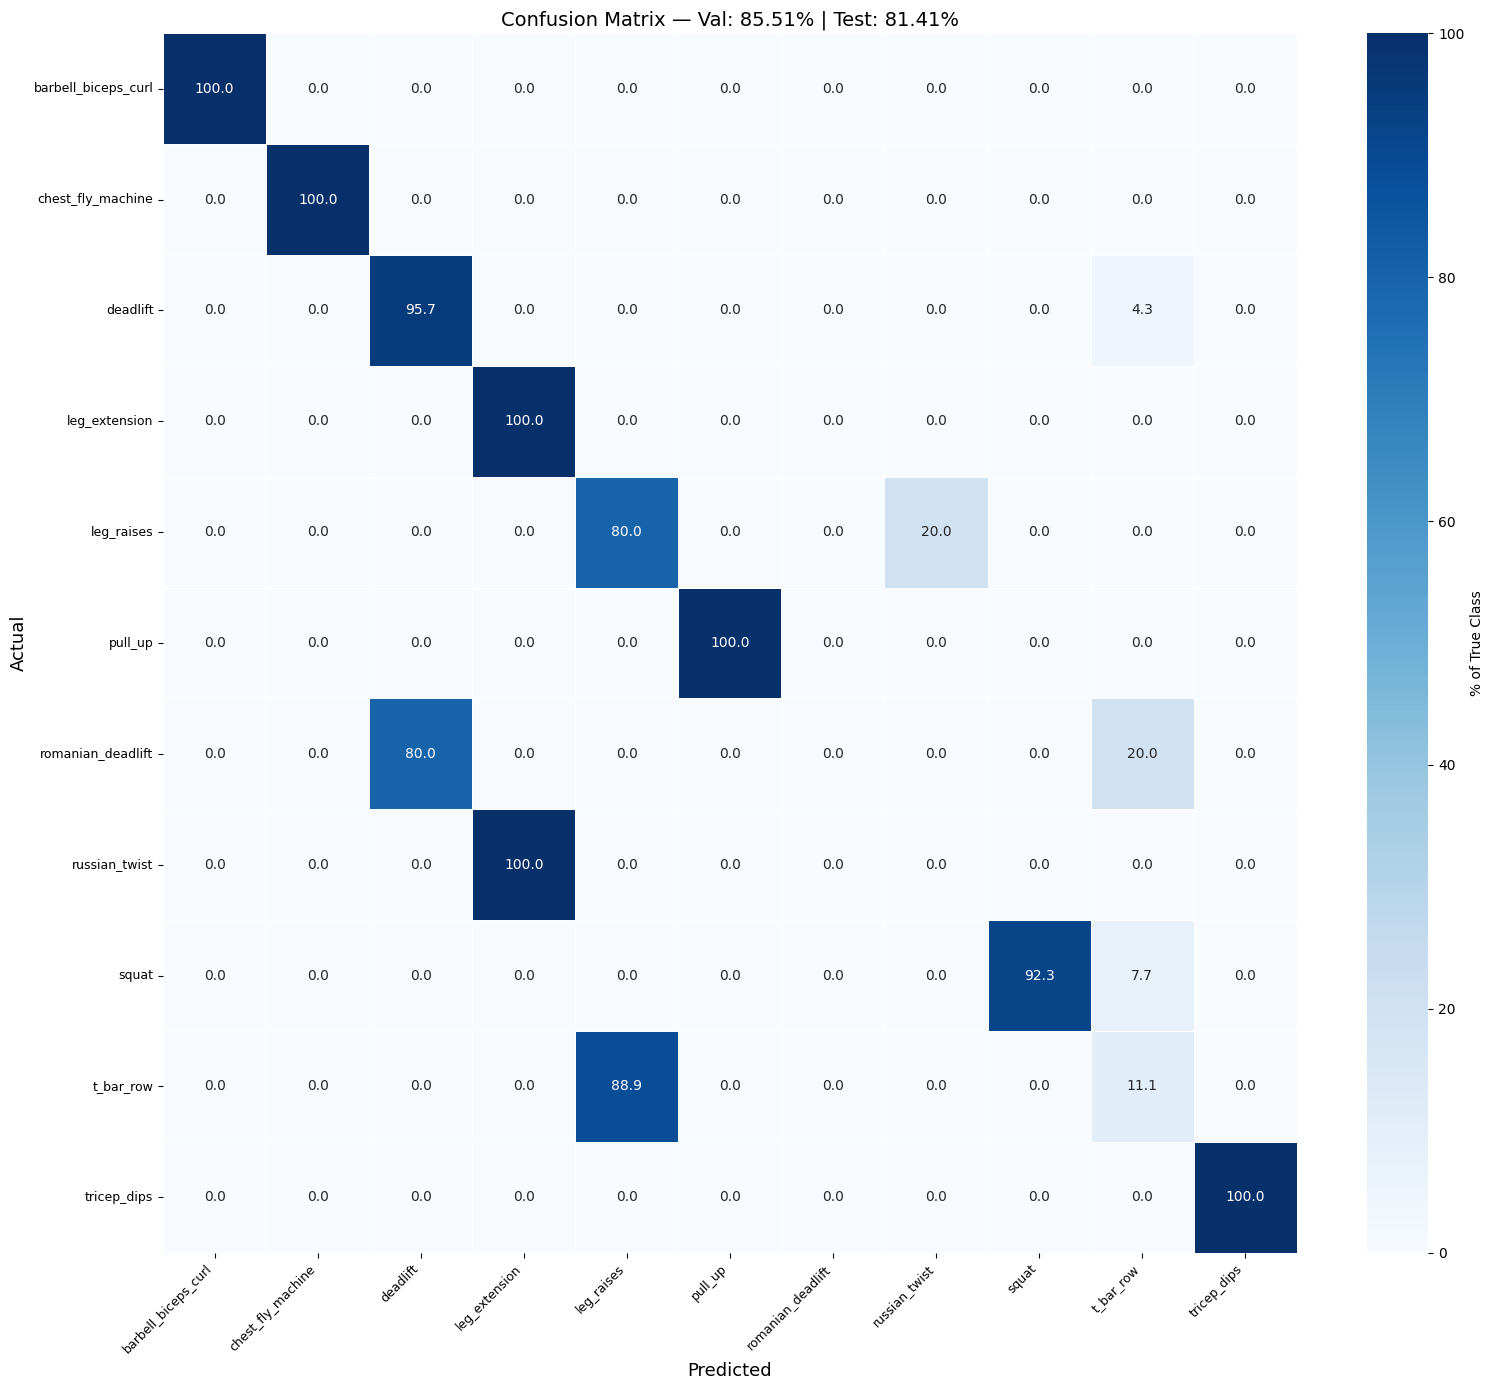

✅ Confusion matrix saved


In [76]:
cm     = confusion_matrix(y_test, y_pred, labels=actual_labels)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm_pct,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    xticklabels=actual_class_names,
    yticklabels=actual_class_names,
    cbar_kws={'label': '% of True Class'},
    linewidths=0.5
)
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('Actual',    fontsize=13)
plt.title(
    f'Confusion Matrix — Val: {best_val_acc*100:.2f}% | Test: {test_acc*100:.2f}%',
    fontsize=14
)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig(f'{ARTIFACTS_DIR}/confusion_matrix.png', dpi=150)
plt.show()
print('✅ Confusion matrix saved')


In [77]:
wrong_idx = np.where(y_test != y_pred)[0]
print(f'\nMisclassified Samples ({len(wrong_idx)} total):')
print(f"{'True':<25} {'Predicted':<25} {'Confidence':>10}")
print("-" * 62)
for i in wrong_idx[:15]:
    true_name = CLASS_NAMES[y_test[i]]
    pred_name = CLASS_NAMES[y_pred[i]]
    conf      = y_pred_probs[i][y_pred[i]] * 100
    print(f"{true_name:<25} {pred_name:<25} {conf:>9.1f}%")


Misclassified Samples (37 total):
True                      Predicted                 Confidence
--------------------------------------------------------------
deadlift                  t_bar_row                      91.4%
leg_raises                russian_twist                  93.5%
leg_raises                russian_twist                  93.6%
leg_raises                incline_bench_press            43.4%
leg_raises                russian_twist                  84.6%
leg_raises                russian_twist                  98.5%
leg_raises                russian_twist                  99.4%
leg_raises                russian_twist                  98.8%
leg_raises                russian_twist                  33.9%
leg_raises                russian_twist                  87.4%
leg_raises                russian_twist                  99.6%
leg_raises                russian_twist                  99.7%
leg_raises                russian_twist                  87.5%
romanian_deadlift   

---
# PHASE 6 — Save Artifacts

Three files are saved. All three are required at inference time:
- `gru_model.h5` — the trained BiLSTM model (name kept for API compatibility)
- `scaler.pkl` — the fitted StandardScaler
- `label_mapping.json` — int → exercise name mapping

Copy these to your BioFitCoach project `ml_models/` folder.

In [ ]:
# ── PHASE 6: SAVE ARTIFACTS ───────────────────────────────────────────────
import os, json, joblib

os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# 1. Model — use .keras format (no warning)
model.save(f'{ARTIFACTS_DIR}/gru_model.keras')
print(f'✅ Model saved      : {ARTIFACTS_DIR}/gru_model.keras')

# 2. Scaler
joblib.dump(scaler, SCALER_PATH)
print(f'✅ Scaler saved     : {SCALER_PATH}')

# 3. Label mapping
with open(LABEL_MAP_PATH, 'w') as f:
    json.dump(label_mapping, f, indent=2)
print(f'✅ Label map saved  : {LABEL_MAP_PATH}')

# 4. Full config
config_summary = {
    'num_features':      len(feature_cols),   # ✅ fixed — was NUM_FEATURES
    'sequence_length':   SEQUENCE_LENGTH,
    'num_classes':       NUM_CLASSES,
    'class_names':       CLASS_NAMES,
    'label_mapping':     label_mapping,
    'best_val_accuracy': round(float(best_val_acc), 4),
    'test_accuracy':     round(float(test_acc), 4),
}
with open(f'{ARTIFACTS_DIR}/model_config.json', 'w') as f:
    json.dump(config_summary, f, indent=2)
print(f'✅ Config saved     : {ARTIFACTS_DIR}/model_config.json')

print(f'''
=====================================
  TRAINING COMPLETE
=====================================
  Val Accuracy  : {best_val_acc*100:.2f}%
  Test Accuracy : {test_acc*100:.2f}%git
  Classes       : {NUM_CLASSES}
  Features      : {len(feature_cols)}
  Sequence len  : {SEQUENCE_LENGTH} frames
=====================================
''')

✅ Model saved      : ./ml_models/gru_model.keras
✅ Scaler saved     : ./ml_models/scaler.pkl
✅ Label map saved  : ./ml_models/label_mapping.json
✅ Config saved     : ./ml_models/model_config.json

  TRAINING COMPLETE
  Val Accuracy  : 85.51%
  Test Accuracy : 81.41%
  Classes       : 18
  Features      : 48
  Sequence len  : 30 frames



---
# PHASE 7 — Update feature_engineering.py for Inference

⚠️ **Important**: Now that we use 48 features (not 21), we need to update the `extract_frame_features` function in `module_2_exercise_coach/services/feature_engineering.py` to match exactly what we trained on.

The cell below generates the exact code to paste into your `feature_engineering.py` file.

In [ ]:
# ── Print the exact feature_engineering.py update needed ─────────────────
print('''
📋 COPY THIS into feature_engineering.py (replace the existing constants):

NUM_FEATURES    = 48    # 13 joints × 3 coords + 9 angles
SEQUENCE_LENGTH = 30    # frames per GRU/BiLSTM input

KEY_LANDMARKS = {
    "left_shoulder":  11, "right_shoulder": 12,
    "left_elbow":     13, "right_elbow":    14,
    "left_wrist":     15, "right_wrist":    16,
    "left_hip":       23, "right_hip":      24,
    "left_knee":      25, "right_knee":     26,
    "left_ankle":     27, "right_ankle":    28,
    "nose":            0,
}

The extract_frame_features() function in this notebook
is the EXACT same function to use in feature_engineering.py.
Replace compute_features() with extract_frame_features().

Also update shared/config.py:
    sequence_length: int = 30   (was 25)
''')

In [ ]:
# ── Optional: Quick single-frame inference test ───────────────────────────
# Tests that the model, scaler, and label mapping all load correctly

print('🧪 Testing model reload...')

loaded_model  = tf.keras.models.load_model(MODEL_PATH)
loaded_scaler = joblib.load(SCALER_PATH)
with open(LABEL_MAP_PATH) as f:
    loaded_labels = json.load(f)

# Create a dummy sequence (zeros — just to test shapes)
dummy = np.zeros((1, SEQUENCE_LENGTH, NUM_FEATURES), dtype=np.float32)
dummy_scaled = loaded_scaler.transform(dummy.reshape(-1, NUM_FEATURES)).reshape(1, SEQUENCE_LENGTH, NUM_FEATURES)
probs = loaded_model.predict(dummy_scaled, verbose=0)

print(f'✅ Model reloaded successfully')
print(f'   Input shape  : {dummy_scaled.shape}')
print(f'   Output shape : {probs.shape}  (1 sample, {NUM_CLASSES} class probabilities)')
print(f'   Predicted class: {loaded_labels[str(np.argmax(probs[0]))]} ({np.max(probs[0]):.3f} confidence)')
print(f'\n🎉 All artifacts verified and ready for deployment!')